# Data cascades in the inventory system

A simulation of four stores and 20 products for one year. Every day the system forecasts
the demand from the **recorded** sales of the last four weeks and reorders when the stock
it *believes* is on the shelf gets low. The order size depends on the shelf capacity, which
the system computes from the case dimensions in the product master data.

Pick a scenario, then switch on the early fixes one by one (and run the notebook again).

In [1]:
import altair as alt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from inventory_data import master, sim, viz

alt.renderers.enable("png", scale_factor=2)  # static images: GitHub shows them
viz.enable()

In [2]:
SCENARIO = "everything at once"
# "clean data", "Target Canada: wrong case dimensions", "phantom inventory",
# or "everything at once"
VALIDATE = False  # validate the product master data at entry (see 13)
COUNT_RULE = False  # rule: no sales for 3 days but stock in the system -> count
CENSORED = False  # forecast only from days without a stock-out that the system knows about

In [3]:
stores = master.stores(include_new=False).head(4)
products = (
    master.products()
    .query(
        "id in [101, 102, 103, 106, 108, 112, 116, 117, 118, 123, 124, 126, 127, 132, 133, "
        "138, 143, 146, 150, 151]"
    )
    .reset_index(drop=True)
)
planogram = master.shelf_volume_l(products, stores)
world = sim.make_world(stores, products, sim.dates("2024-01-01", "2024-12-31"), seed=3)
lead = products.supplier_id.map(master.suppliers().set_index("id").lead_time_days).to_numpy()

wrong = products.copy()
dims = ["case_length_cm", "case_width_cm", "case_height_cm"]
inches = products.id.isin([101, 106, 112, 123, 126])
swapped = products.id.isin([102, 117, 132, 143, 150])
wrong.loc[inches, dims] = (products.loc[inches, dims] / 2.54).round(1)
wrong.loc[swapped, "case_height_cm"] = products.loc[swapped, "case_width_cm"] * 3
wrong_ids = set(products.id[inches | swapped])
weekday = sim.WEEKDAY[world.days.dayofweek]

In [4]:
def run(scenario, validate=False, count_rule=False, censored=False):
    tc = scenario in ("Target Canada: wrong case dimensions", "everything at once")
    phantom = scenario in ("phantom inventory", "everything at once")
    master_data = wrong if tc and not validate else products
    capacity = sim.shelf_capacity(master_data, stores, planogram)
    inv = sim.Inventory(
        world.demand,
        capacity,
        master_data.case_pack.to_numpy(float),
        lead,
        products.shelf_life_days.to_numpy(),
        (products.unit == "count").to_numpy(),
        shrink_rate=0.015 if phantom else 0.003,
        count_every=None if phantom else 7,
        seed=1,
    )
    forecasts = np.zeros(world.demand.shape)
    quiet = np.zeros(capacity.shape)

    def policy(d, inv):
        o = inv.o
        if d < 28:
            f = world.lam[d]
        else:
            hist = o["sales"][d - 27 : d + 1] / weekday[d - 27 : d + 1, None, None]
            if censored:
                ok = o["on_hand_system"][d - 27 : d + 1] > 0
                f = np.where(
                    ok.sum(0) > 0, (hist * ok).sum(0) / np.maximum(ok.sum(0), 1), hist.mean(0)
                )
            else:
                f = hist.mean(0)
            f = f * weekday[min(d + 1, len(weekday) - 1)]
        forecasts[d] = f
        if count_rule:
            quiet[:] = np.where((o["sales"][d] == 0) & (inv.system > 0) & (f > 0.5), quiet + 1, 0)
            recount = quiet >= 3
            inv.system[recount] = inv.true[recount]
            quiet[recount] = 0
        position = inv.system + inv.on_order()
        reorder_point = f * (lead + 1) * 1.3
        target = np.minimum(np.maximum(capacity, reorder_point), capacity * 1.5)
        return np.where(position < reorder_point, target - position, 0)

    out = inv.run(policy)
    return out, forecasts

In [5]:
def weekly(out, forecasts, label):
    week = (world.days - world.days[0]).days // 7
    rows = []
    for w in range(week.max() + 1):
        m = week == w
        demand, sales = world.demand[m].sum(), out["sales"][m].sum()
        rows.append(
            {
                "week": world.days[m][0],
                "run": label,
                "lost sales (% of demand)": 100 * out["lost"][m].sum() / demand,
                "waste (% of sales)": 100 * out["waste"][m].sum() / max(sales, 1),
                "forecast error vs recorded sales": np.abs(forecasts[m] - out["sales"][m]).mean(),
                "system says in stock, shelf empty (%)": 100
                * ((out["on_hand_system"][m] > 0) & (out["on_hand"][m] <= 0)).mean(),
            }
        )
    return pd.DataFrame(rows)

In [6]:
base = weekly(*run("clean data"), "clean data")
chosen = weekly(*run(SCENARIO, VALIDATE, COUNT_RULE, CENSORED), "selected scenario")

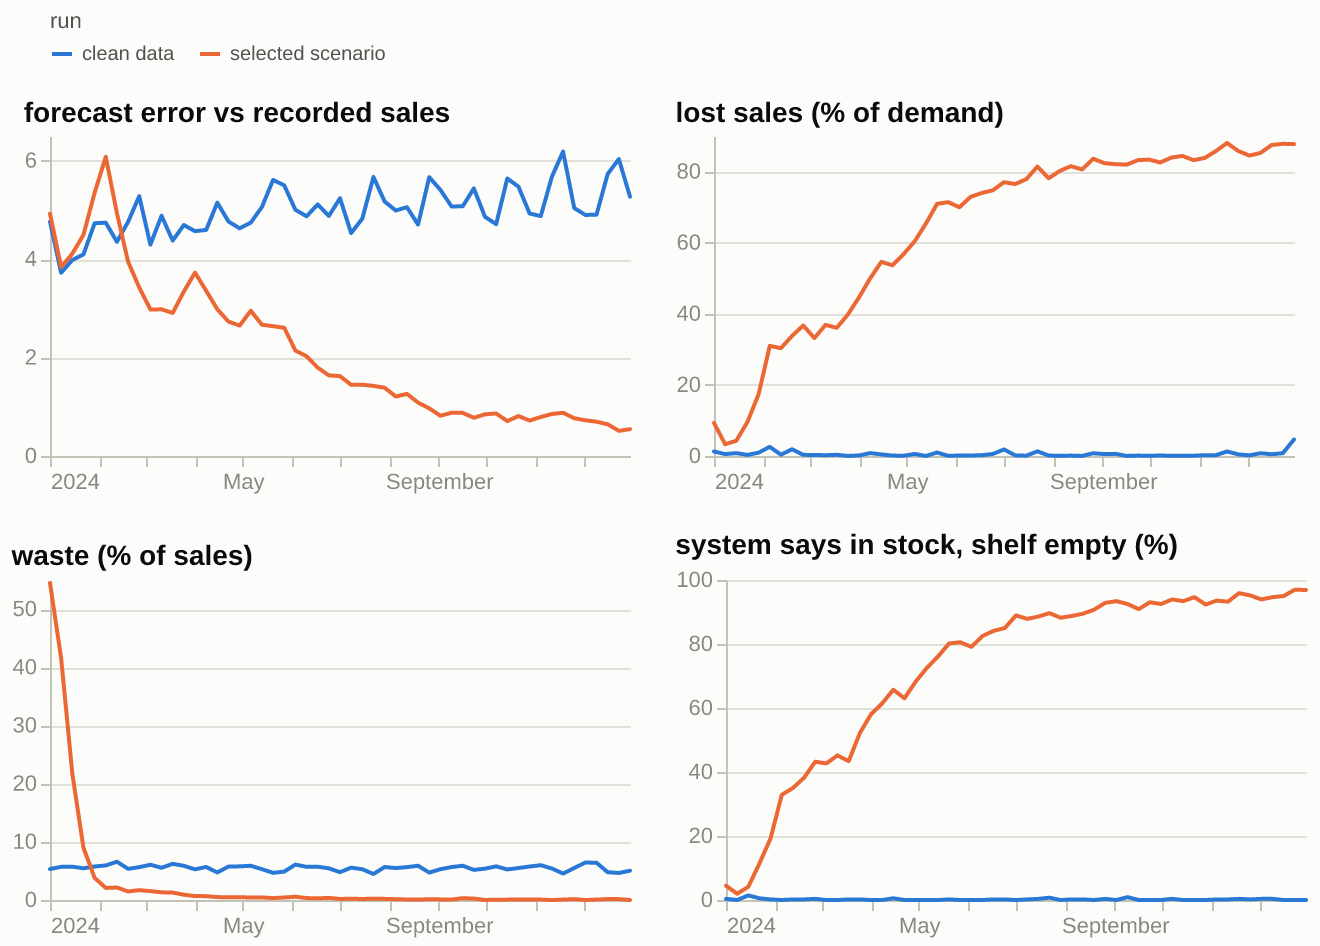

Averages over the year:

,lost sales (% of demand),waste (% of sales),forecast error vs recorded sales,"system says in stock, shelf empty (%)"
run,,,,
clean data,0.56,5.51,4.98,0.18
selected scenario,63.79,2.87,2.13,72.21


In [7]:
both = pd.concat([base, chosen]).melt(id_vars=["week", "run"], var_name="metric")


def panel(metric):
    c = (
        alt.Chart(both[both.metric == metric])
        .mark_line()
        .encode(
            x=alt.X("week:T", title=None),
            y=alt.Y("value:Q", title=None),
            color=alt.Color("run:N", sort=["clean data", "selected scenario"]),
            tooltip=["run", alt.Tooltip("week:T"), alt.Tooltip("value:Q", format=".2f")],
        )
    )
    return c.properties(width=290, height=160, title=metric)


metrics = list(base.columns[2:])
grid = alt.vconcat(
    alt.hconcat(panel(metrics[2]), panel(metrics[0])),
    alt.hconcat(panel(metrics[1]), panel(metrics[3])),
)
totals = pd.concat([base, chosen]).groupby("run", sort=False)[metrics].mean().round(2)
display(grid)
display(Markdown("Averages over the year:"))
display(totals)

## All scenarios

Look at the third column: the **forecast error against the recorded sales** (the metric a
data scientist sees) does not show the problems. With phantom inventory it even gets
*better*: the shelves are empty, the recorded sales are zero, and zero is easy to predict.
This is goodness-of-fit, not goodness-of-data.

In [8]:
combos = [
    ("clean data", {}),
    ("Target Canada: wrong case dimensions", {}),
    ("Target Canada: wrong case dimensions", {"validate": True}),
    ("phantom inventory", {}),
    ("phantom inventory", {"count_rule": True}),
    ("phantom inventory", {"count_rule": True, "censored": True}),
    ("everything at once", {}),
    ("everything at once", {"validate": True, "count_rule": True, "censored": True}),
]
table = []
for name, fixes in combos:
    w = weekly(*run(name, **fixes), name)
    table.append(
        {
            "scenario": name,
            "fixes": ", ".join(fixes) or "none",
            **w.iloc[:, 2:].mean().round(2).to_dict(),
        }
    )
overview = pd.DataFrame(table)

In [9]:
overview

,scenario,fixes,lost sales (% of demand),waste (% of sales),forecast error vs recorded sales,"system says in stock, shelf empty (%)"
0,clean data,none,0.56,5.51,4.98,0.18
1,Target Canada: wrong case dimensions,none,5.03,33.34,4.72,0.82
2,Target Canada: wrong case dimensions,validate,0.56,5.51,4.98,0.18
3,phantom inventory,none,65.07,1.08,2.31,68.42
4,phantom inventory,count_rule,9.38,2.95,5.12,19.33
5,phantom inventory,"count_rule, censored",9.37,2.95,5.12,19.39
6,everything at once,none,63.79,2.87,2.13,72.21
7,everything at once,"validate, count_rule, censored",9.37,2.95,5.12,19.39


## What happens (a data cascade)

- **Target Canada.** Case dimensions in inches are read as cm: the system thinks 16 times
  more cases fit on the shelf and orders far too much; perishables spoil. Dimensions that
  are too large have the opposite effect: small orders, empty shelves.
- **Phantom inventory.** Theft and damage are not recorded and nobody counts. The system
  believes the stock is on the shelf, so it does not reorder. The shelf is empty, the
  recorded sales go to zero, the forecast learns "no demand", and the system orders even
  less. The problem compounds and is invisible in the model metrics.
- **Sales are not demand** ("raw data is an oxymoron"): on days with a stock-out, the sales
  record how much was on the shelf, not how much customers wanted. A forecast that skips
  the stock-out days does not help here: the system does not *know* that the shelf is
  empty. The fix must come from outside the data (a physical count).
- The fixes are cheap and early: validate data at entry, a rule that triggers a count, and
  a forecast that knows about censored days. Each fix works at a different interface of
  the system: data quality is a system-wide concern.